In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from scipy.stats import shapiro
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df = pd.read_csv('/content/sample_data/Customer_Category_Classifier_Dataset.csv')
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [ ]:
df.shape

(8068, 11)

In [ ]:
#how many features?
print(f"There are {df.shape[1]-1} features in this dataset")
# classification or regression?
print("This is a 'Multi-Class Classification' problem")
#How many data points
print(f"There are {df.shape[0]} data points.")
#What kind of features?
print(set(df.dtypes))
print(df.dtypes[:10])
#Both of datas exist here--> Quantitative and Categorical

There are 10 features in this dataset
This is a 'Multi-Class Classification' problem
There are 8068 data points.
{dtype('float64'), dtype('O'), dtype('int64')}
ID                   int64
Gender              object
Ever_Married        object
Age                  int64
Graduated           object
Profession          object
Work_Experience    float64
Spending_Score      object
Family_Size        float64
Var_1               object
dtype: object


In [ ]:
# numerical features
numerical_data = df.select_dtypes(include=['int64', 'float64'])
numerical_features = numerical_data.columns.tolist()

# categorical features
categorical_data = df.select_dtypes(include='object')
categorical_features = categorical_data.columns.tolist()

quantitative_features = numerical_features.copy()

# Print results
print(f"Feature types:\n")
print(f'There are {len(categorical_features)-1} categorical features:\n{categorical_features[:5]}\n')
print(f'There are {len(quantitative_features)} quantitative features:\n{quantitative_features}')

Feature types:

There are 6 categorical features:
['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score']

There are 4 quantitative features:
['ID', 'Age', 'Work_Experience', 'Family_Size']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


In [ ]:
df['Segmentation'].value_counts()

,count
Segmentation,
D,2268
A,1972
C,1970
B,1858


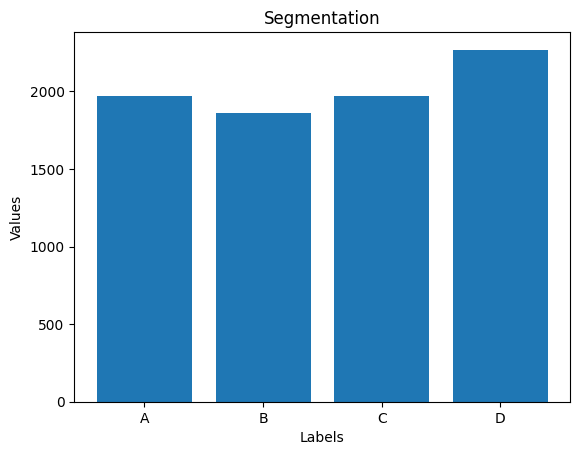

In [ ]:
#Bar chart
labels = ['A', 'B', 'C', 'D']
values = [1972, 1858, 1970, 2268]
plt.bar(labels, values)
plt.xlabel("Labels")
plt.ylabel("Values")
plt.title("Segmentation")
plt.show()

In [ ]:
#Removing ID column
df = df.drop('ID', axis=1)

In [ ]:
# Get the shape of the dataset (number of rows and columns)
print(df.shape)
#Duplicate values
print(df.duplicated().sum())
# Check for missing values
print(df.isnull().sum())

(8068, 10)
417
Gender               0
Ever_Married       140
Age                  0
Graduated           78
Profession         124
Work_Experience    829
Spending_Score       0
Family_Size        335
Var_1               76
Segmentation         0
dtype: int64


In [ ]:
# Remove duplicates
df = df.drop_duplicates()

print("After removing duplicates:", df.duplicated().sum())
print("New dataset shape:", df.shape)

After removing duplicates: 0
New dataset shape: (7651, 10)


In [ ]:
categorical_data.describe().T

,count,unique,top,freq
Gender,8068,2,Male,4417
Ever_Married,7928,2,Yes,4643
Graduated,7990,2,Yes,4968
Profession,7944,9,Artist,2516
Spending_Score,8068,3,Low,4878
Var_1,7992,7,Cat_6,5238
Segmentation,8068,4,D,2268


In [ ]:
numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,8068.0,463479.214551,2595.381232,458982.0,461240.75,463472.5,465744.25,467974.0
Age,8068.0,43.466906,16.711696,18.0,30.00,40.0,53.00,89.0
Work_Experience,7239.0,2.641663,3.406763,0.0,0.00,1.0,4.00,14.0
Family_Size,7733.0,2.850123,1.531413,1.0,2.00,3.0,4.00,9.0


In [ ]:
numerical_data.var()

,0
ID,6.736004e+06
Age,2.792808e+02
Work_Experience,1.160603e+01
Family_Size,2.345227e+00


In [ ]:
numerical_data.skew()

,0
ID,0.002435
Age,0.696021
Work_Experience,1.306226
Family_Size,1.010804


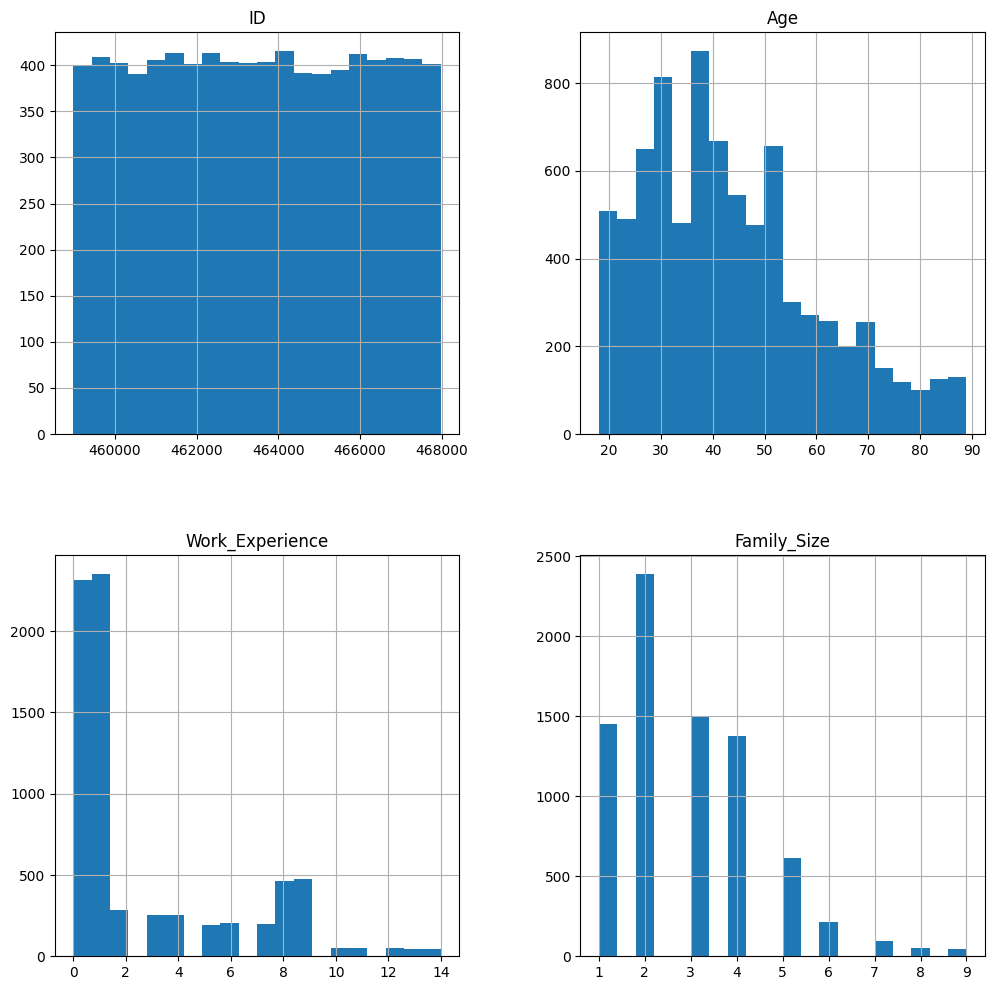

In [ ]:
numerical_data.hist(figsize=(12,12),bins=20)
plt.show()

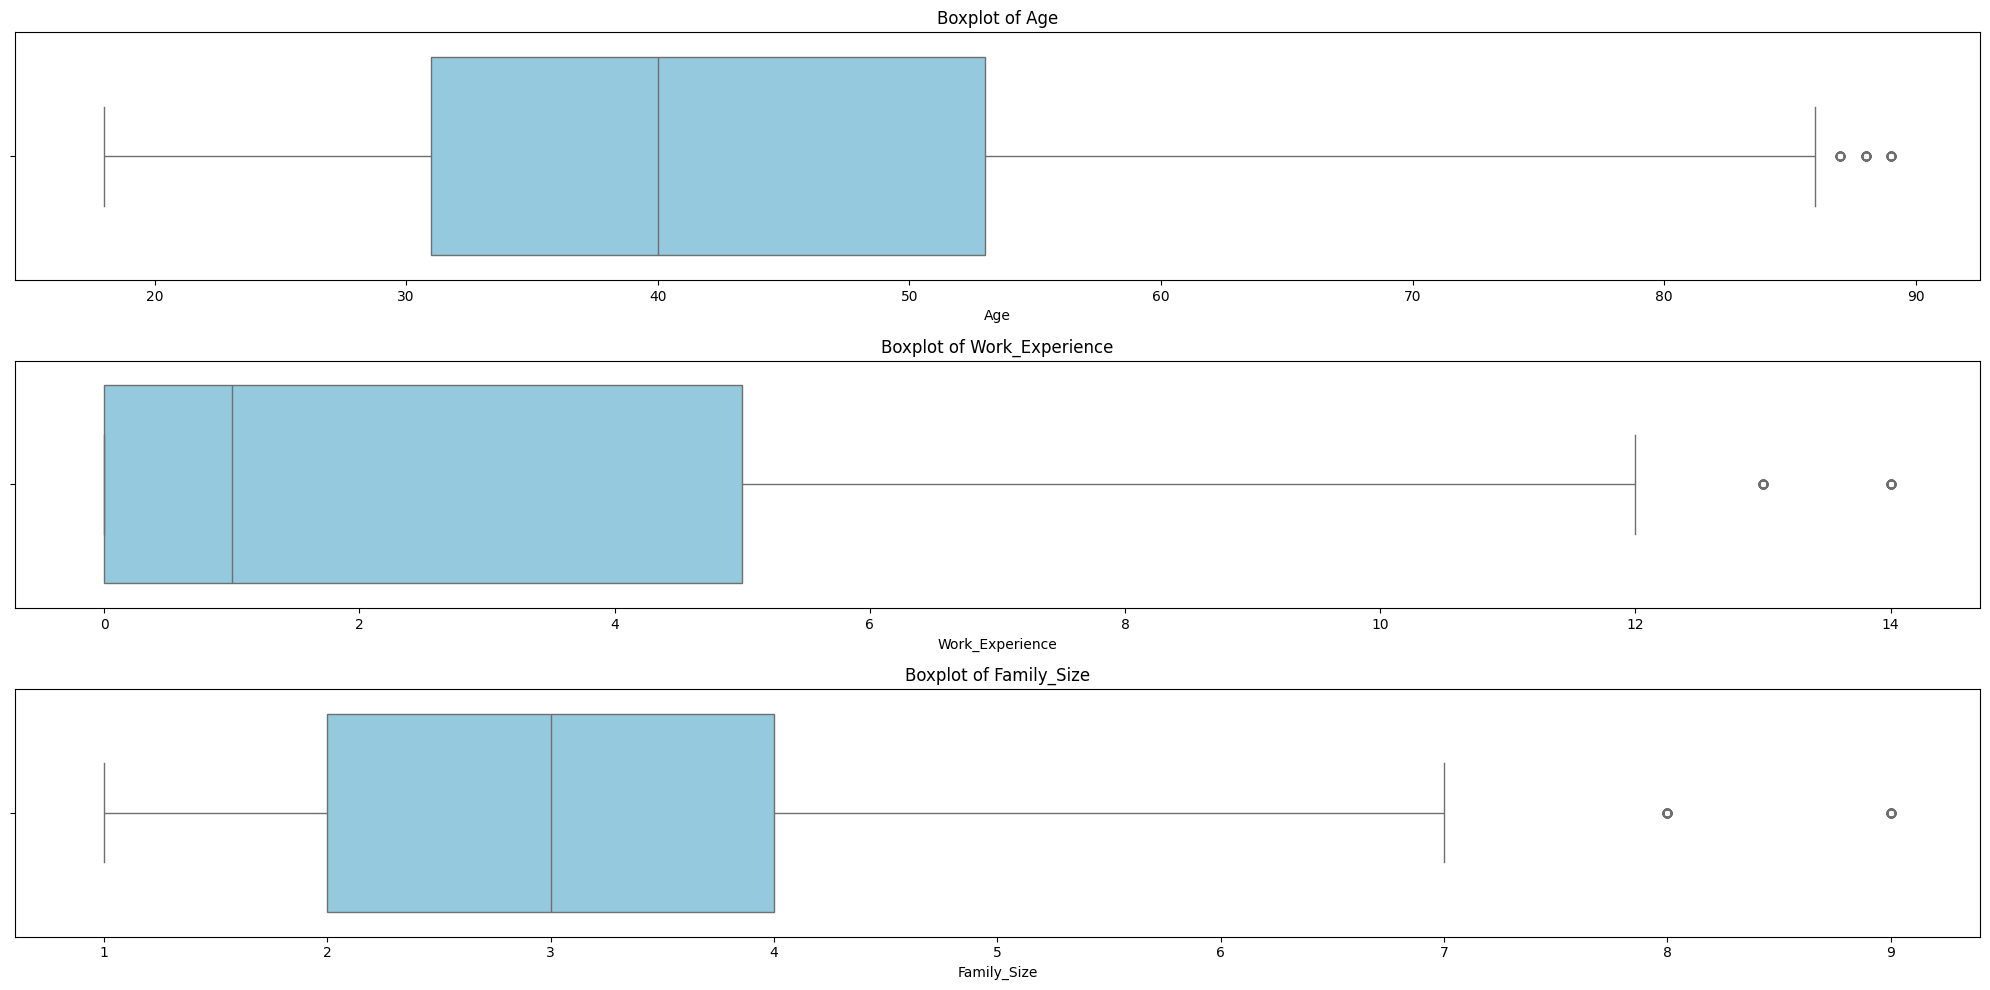

In [ ]:
# Select only numerical columns for boxplot analysis
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Set up the figure
plt.figure(figsize=(20, 10))

# Plot boxplots for each numerical feature
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()
plt.show()

In [ ]:
correlation_matrix = numerical_data.corr()
correlation_matrix

,ID,Age,Work_Experience,Family_Size
ID,1.000000,-0.005055,-0.030688,0.011801
Age,-0.005055,1.000000,-0.190789,-0.280517
Work_Experience,-0.030688,-0.190789,1.000000,-0.063234
Family_Size,0.011801,-0.280517,-0.063234,1.000000


In [ ]:
#Missing_values
df.isna().sum()

,0
Gender,0
Ever_Married,140
Age,0
Graduated,78
Profession,124
Work_Experience,806
Spending_Score,0
Family_Size,332
Var_1,76
Segmentation,0


In [ ]:
print((df.isna().sum()/len(df))*100)

Gender              0.000000
Ever_Married        1.829826
Age                 0.000000
Graduated           1.019475
Profession          1.620703
Work_Experience    10.534571
Spending_Score      0.000000
Family_Size         4.339302
Var_1               0.993334
Segmentation        0.000000
dtype: float64


In [ ]:
# Fill categorical column(s) with mode
df['Ever_Married'] = df['Ever_Married'].fillna(df['Ever_Married'].mode()[0])
df['Graduated'] = df['Graduated'].fillna(df['Graduated'].mode()[0])
df['Profession'] = df['Profession'].fillna(df['Profession'].mode()[0])
df['Var_1'] = df['Var_1'].fillna(df['Var_1'].mode()[0])

# Fill numerical columns with median
df['Family_Size'] = df['Family_Size'].fillna(df['Family_Size'].median())
df['Work_Experience'] = df['Work_Experience'].fillna(df['Work_Experience'].median())

In [ ]:
df.isna().sum()

,0
Gender,0
Ever_Married,0
Age,0
Graduated,0
Profession,0
Work_Experience,0
Spending_Score,0
Family_Size,0
Var_1,0
Segmentation,0


In [ ]:
non_numeric_cols = df.select_dtypes(exclude=['number']).columns.tolist()
print(non_numeric_cols)

['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1', 'Segmentation']


In [ ]:
#one-hot encoding on non-numeric columns
df = pd.get_dummies(df, columns=non_numeric_cols, drop_first=True)

print(df.head())

   Age  Work_Experience  Family_Size  Gender_Male  Ever_Married_Yes  \
0   22              1.0          4.0         True             False   
1   38              1.0          3.0        False              True   
2   67              1.0          1.0        False              True   
3   67              0.0          2.0         True              True   
4   40              1.0          6.0        False              True   

   Graduated_Yes  Profession_Doctor  Profession_Engineer  \
0          False              False                False   
1           True              False                 True   
2           True              False                 True   
3           True              False                False   
4           True              False                False   

   Profession_Entertainment  Profession_Executive  ...  Spending_Score_Low  \
0                     False                 False  ...                True   
1                     False                 False  ...  

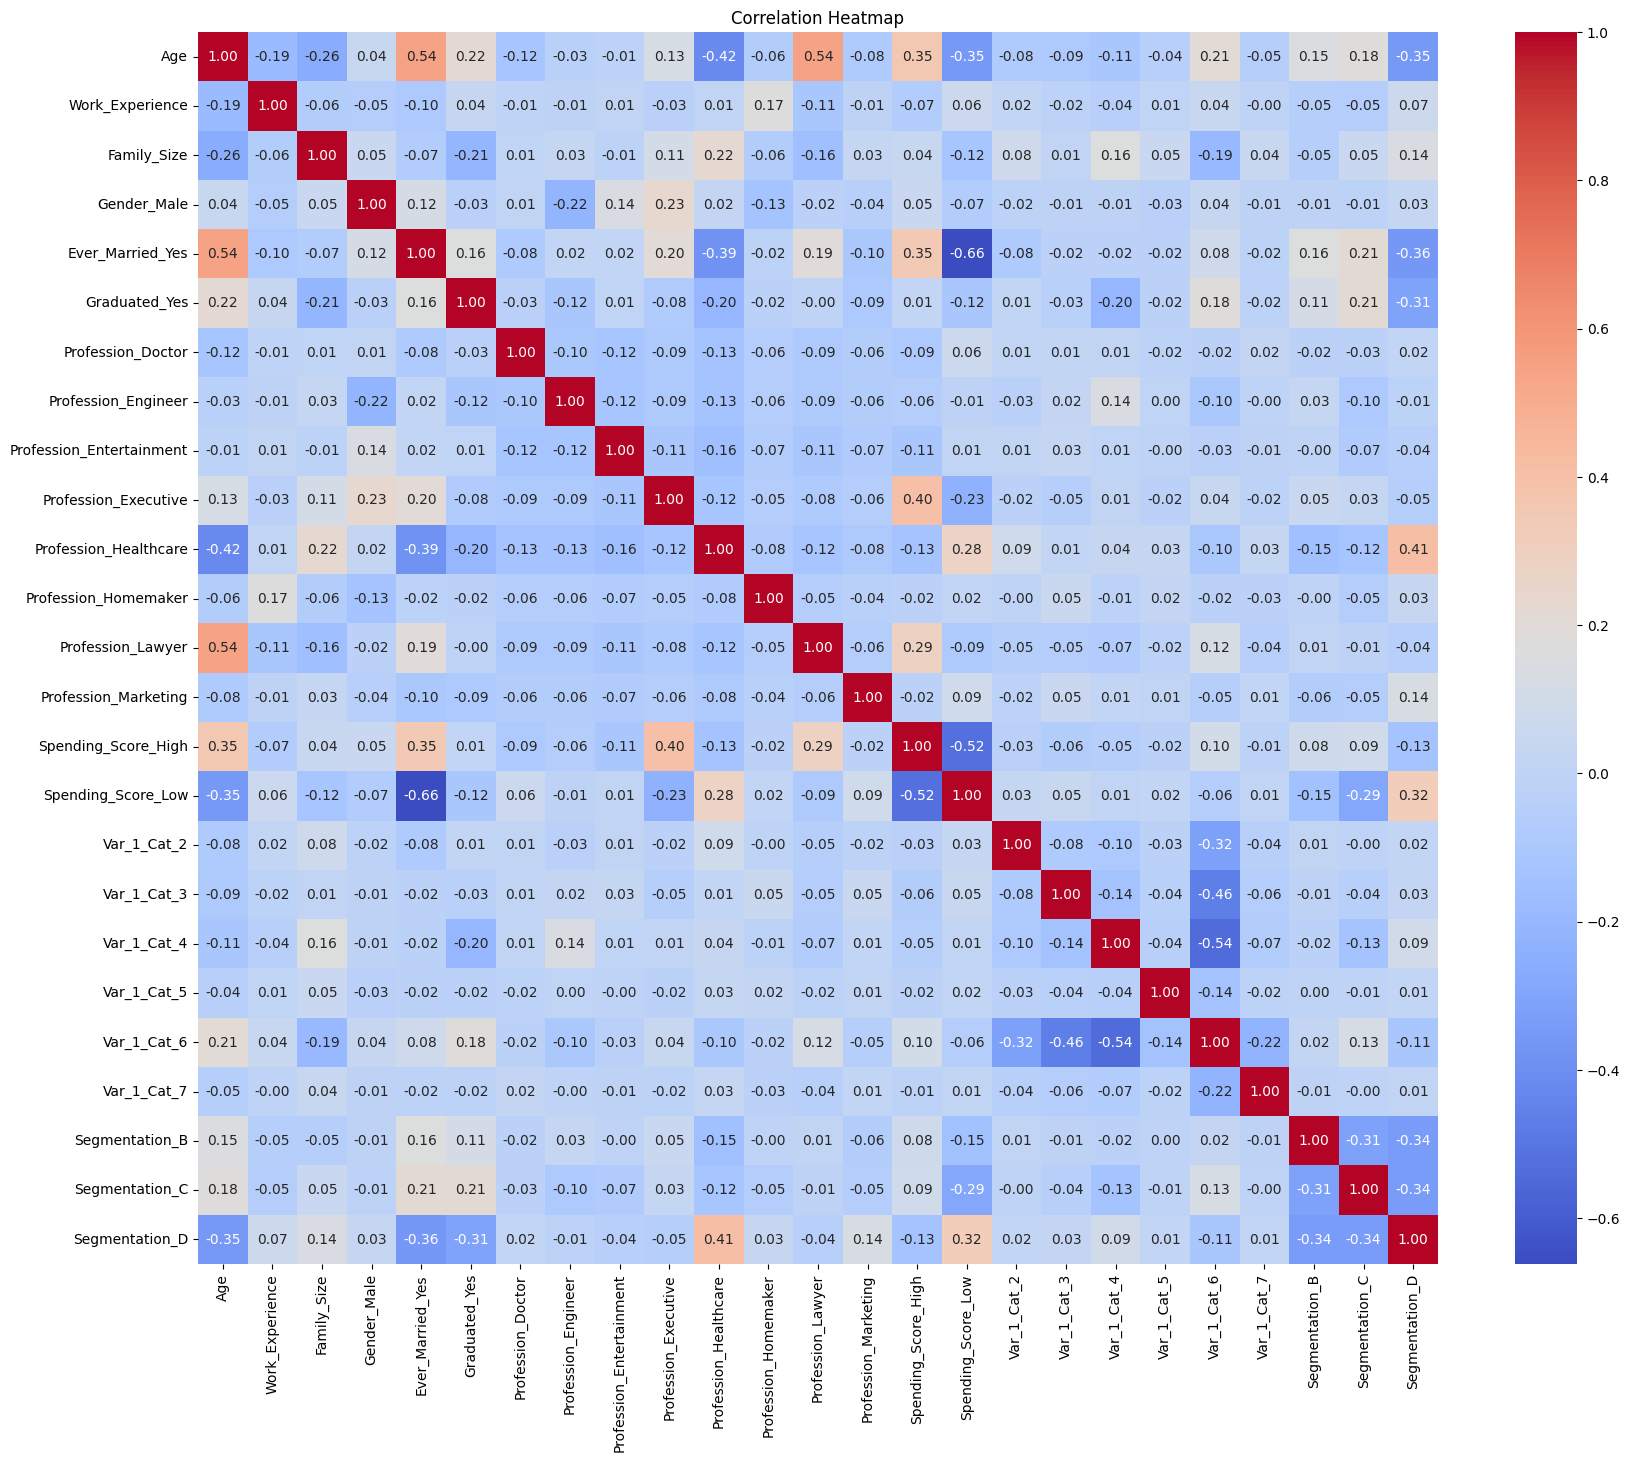

In [ ]:
plt.figure(figsize=(20, 16))
sns.heatmap(df.corr(), annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
import numpy as np
for i in df.columns.to_list():
    var=np.var(df[i])
    print(f"{i}: {round(var,2)}")

Age: 273.05
Work_Experience: 10.92
Family_Size: 2.3
Gender_Male: 0.25
Ever_Married_Yes: 0.24
Graduated_Yes: 0.23
Profession_Doctor: 0.08
Profession_Engineer: 0.08
Profession_Entertainment: 0.11
Profession_Executive: 0.07
Profession_Healthcare: 0.13
Profession_Homemaker: 0.03
Profession_Lawyer: 0.07
Profession_Marketing: 0.04
Spending_Score_High: 0.13
Spending_Score_Low: 0.24
Var_1_Cat_2: 0.05
Var_1_Cat_3: 0.09
Var_1_Cat_4: 0.12
Var_1_Cat_5: 0.01
Var_1_Cat_6: 0.23
Var_1_Cat_7: 0.03
Segmentation_B: 0.18
Segmentation_C: 0.18
Segmentation_D: 0.2


In [ ]:
from sklearn.preprocessing import MinMaxScaler

#MinMaxScaler object
scaler = MinMaxScaler()

numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print(df.head())

        Age  Work_Experience  Family_Size  Gender_Male  Ever_Married_Yes  \
0  0.056338         0.071429        0.375         True             False   
1  0.281690         0.071429        0.250        False              True   
2  0.690141         0.071429        0.000        False              True   
3  0.690141         0.000000        0.125         True              True   
4  0.309859         0.071429        0.625        False              True   

   Graduated_Yes  Profession_Doctor  Profession_Engineer  \
0          False              False                False   
1           True              False                 True   
2           True              False                 True   
3           True              False                False   
4           True              False                False   

   Profession_Entertainment  Profession_Executive  ...  Spending_Score_Low  \
0                     False                 False  ...                True   
1                     Fals

In [ ]:
import numpy as np
for i in df.columns.to_list():
    var=np.var(df[i])
    print(f"{i}: {round(var,2)}")

Age: 0.05
Work_Experience: 0.06
Family_Size: 0.04
Gender_Male: 0.25
Ever_Married_Yes: 0.24
Graduated_Yes: 0.23
Profession_Doctor: 0.08
Profession_Engineer: 0.08
Profession_Entertainment: 0.11
Profession_Executive: 0.07
Profession_Healthcare: 0.13
Profession_Homemaker: 0.03
Profession_Lawyer: 0.07
Profession_Marketing: 0.04
Spending_Score_High: 0.13
Spending_Score_Low: 0.24
Var_1_Cat_2: 0.05
Var_1_Cat_3: 0.09
Var_1_Cat_4: 0.12
Var_1_Cat_5: 0.01
Var_1_Cat_6: 0.23
Var_1_Cat_7: 0.03
Segmentation_B: 0.18
Segmentation_C: 0.18
Segmentation_D: 0.2



Cluster distribution:
Cluster
2    2580
0    2053
1    1560
3    1458
Name: count, dtype: int64


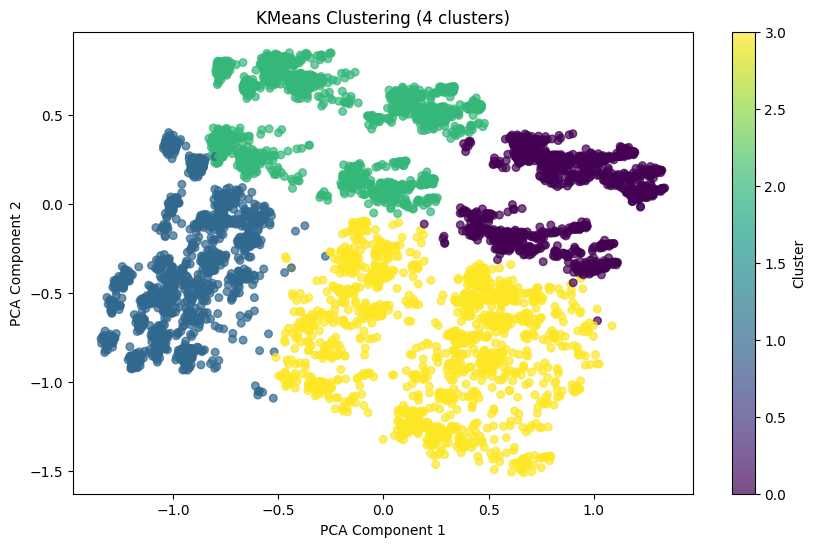


Cross-tab between true Segmentation_B and KMeans clusters:
Cluster            0     1     2     3
Segmentation_B                        
False           1411  1362  2036  1028
True             642   198   544   430
Cluster            0     1     2     3
Segmentation_C                        
False           1133  1397  2156  1144
True             920   163   424   314
Cluster            0    1     2     3
Segmentation_D                       
False           1924  672  1777  1182
True             129  888   803   276


In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Drop segmentation dummy columns if present (since clustering is unsupervised)
X_cluster = df.drop(['Segmentation_B', 'Segmentation_C', 'Segmentation_D'], axis=1, errors='ignore')

# Apply KMeans with 4 clusters (because A, B, C, D)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster)

# Check cluster distribution
print("\nCluster distribution:")
print(df['Cluster'].value_counts())

# Reduce to 2D with PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='viridis', s=30, alpha=0.7)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("KMeans Clustering (4 clusters)")
plt.colorbar(label='Cluster')
plt.show()

# Compare with actual segmentation labels if available
if 'Segmentation_A' in df.columns or 'Segmentation_B' in df.columns:
    print("\nCross-tab between true Segmentation and KMeans clusters:")
    if 'Segmentation_B' in df.columns:
        print(pd.crosstab(df['Segmentation_B'], df['Cluster']))
    if 'Segmentation_C' in df.columns:
        print(pd.crosstab(df['Segmentation_C'], df['Cluster']))
    if 'Segmentation_D' in df.columns:
        print(pd.crosstab(df['Segmentation_D'], df['Cluster']))


In [ ]:
df['Segmentation_B'].value_counts()

,count
Segmentation_B,
False,5837
True,1814


In [ ]:
df['Segmentation_C'].value_counts()

,count
Segmentation_C,
False,5830
True,1821


In [ ]:
df['Segmentation_D'].value_counts()

,count
Segmentation_D,
False,5555
True,2096


In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = df.drop('Segmentation_B', axis=1)
y = df['Segmentation_B']

# Split the data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5355, 25)
X_test shape: (2296, 25)
y_train shape: (5355,)
y_test shape: (2296,)


In [ ]:
from imblearn.over_sampling import SMOTE

# Applying SMOTE to the training set only
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Train KNN on balanced data
knn = KNeighborsClassifier()
knn.fit(X_train_balanced, y_train_balanced)

# Predict on the original (imbalanced) test set
y_pred_knn_balanced = knn.predict(X_test)

In [ ]:
# accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn_balanced)
print("Accuracy:", knn_accuracy)

Accuracy: 0.7630662020905923


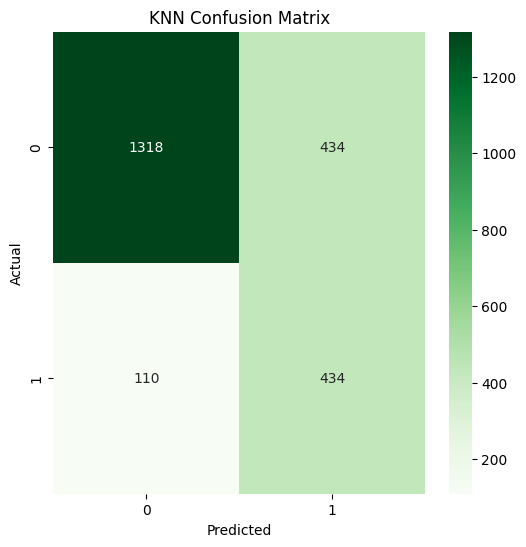

In [ ]:
# confusion matrix
knn_cm = confusion_matrix(y_test, y_pred_knn_balanced)

plt.figure(figsize=(6, 6))
sns.heatmap(knn_cm, annot=True, fmt='d', cmap='Greens', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.title("KNN Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# Classification report
knn_class_report = classification_report(y_test, y_pred_knn_balanced)
print("Classification Report:")
print(knn_class_report)

Classification Report:
              precision    recall  f1-score   support

       False       0.92      0.75      0.83      1752
        True       0.50      0.80      0.61       544

    accuracy                           0.76      2296
   macro avg       0.71      0.78      0.72      2296
weighted avg       0.82      0.76      0.78      2296



In [ ]:
logistic_model = LogisticRegression(class_weight='balanced')
logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

In [ ]:
# Accuracy
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
print("Accuracy:", logistic_accuracy)

Accuracy: 0.7765679442508711


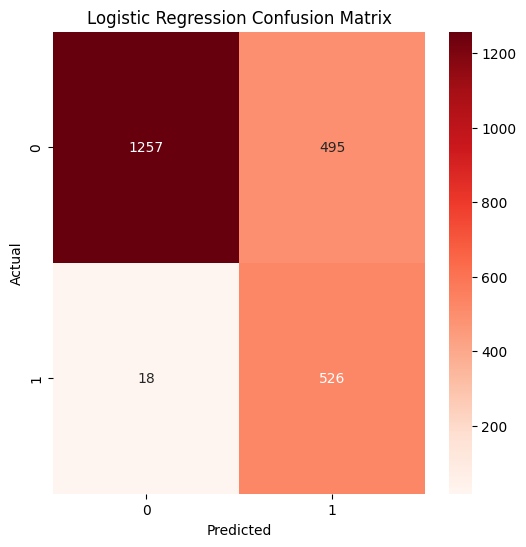

In [ ]:
# confusion matrix
logistic_cm = confusion_matrix(y_test, y_pred_logistic)

# Plotting confusion matrix using seaborn heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(logistic_cm, annot=True, fmt='d', cmap='Reds', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# Classification Report
log_class_report = classification_report(y_test, y_pred_logistic)
print("\nClassification Report:")
print(log_class_report)


Classification Report:
              precision    recall  f1-score   support

       False       0.99      0.72      0.83      1752
        True       0.52      0.97      0.67       544

    accuracy                           0.78      2296
   macro avg       0.75      0.84      0.75      2296
weighted avg       0.87      0.78      0.79      2296



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE

# SMOTE object
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# New class distribution
from collections import Counter
print("Balanced class distribution:", Counter(y_train_balanced))

# Neural network model

model = Sequential([
    Dense(64, input_dim=X_train_balanced.shape[1], activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.001),
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

# EarlyStopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train with balanced data
history = model.fit(X_train_balanced, y_train_balanced,
                             validation_data=(X_test, y_test),
                             epochs=100,
                             batch_size=32,
                             callbacks=[early_stop],
                             verbose=1)
# Evaluate the model
y_pred_nn = (model.predict(X_test) > 0.5).astype(int)

Balanced class distribution: Counter({False: 4085, True: 4085})
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


256/256 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6874 - loss: 0.6228 - val_accuracy: 0.7557 - val_loss: 0.4481
Epoch 2/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8075 - loss: 0.4232 - val_accuracy: 0.7596 - val_loss: 0.4320
Epoch 3/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8238 - loss: 0.3823 - val_accuracy: 0.7626 - val_loss: 0.4166
Epoch 4/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8247 - loss: 0.3801 - val_accuracy: 0.7644 - val_loss: 0.4084
Epoch 5/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8373 - loss: 0.3587 - val_accuracy: 0.7674 - val_loss: 0.3957
Epoch 6/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8325 - loss: 0.3665 - val_accuracy: 0.7700 - val_loss: 0.4103
Epoch 7/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8351 - loss: 0.3678 - val_accuracy: 0.7722 - val_loss: 0.3886
Epoch 8/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8359 - loss: 0.3619 - val_accuracy: 0.7853

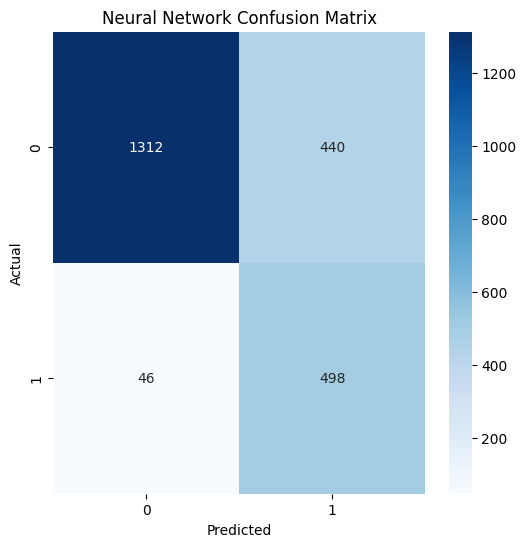

In [ ]:
# Confusion Matrix
nn_cm = confusion_matrix(y_test, y_pred_nn)
plt.figure(figsize=(6, 6))
sns.heatmap(nn_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'])
plt.title("Neural Network Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
#Classification Report
print("\nNeural Network Classification Report:")
print(classification_report(y_test, y_pred_nn))


Neural Network Classification Report:
              precision    recall  f1-score   support

       False       0.97      0.75      0.84      1752
        True       0.53      0.92      0.67       544

    accuracy                           0.79      2296
   macro avg       0.75      0.83      0.76      2296
weighted avg       0.86      0.79      0.80      2296



In [ ]:
# Predict probabilities on the original test set
y_prob_nn_balanced = model.predict(X_test)

# Convert probabilities to class labels (0 or 1)
y_pred_nn_balanced = (y_prob_nn_balanced > 0.5).astype(int)

# evaluate accuracy
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nn_balanced_accuracy = accuracy_score(y_test, y_pred_nn_balanced)
print(f"Neural Network Accuracy (after balancing): {nn_balanced_accuracy:.4f}")

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Neural Network Accuracy (after balancing): 0.7883


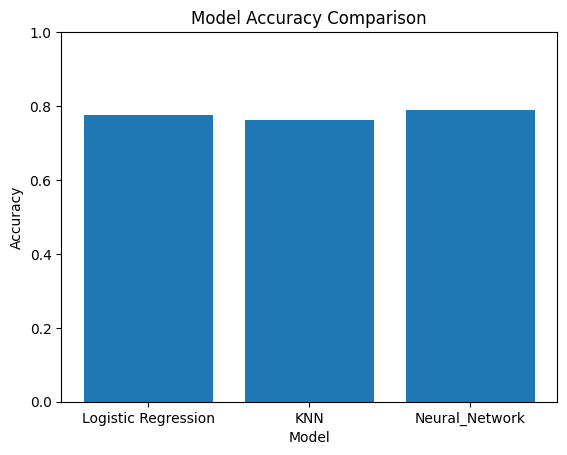

In [ ]:
accuracy_data = {
    'Model': ['Logistic Regression', 'KNN', 'Neural_Network'],
    'Accuracy': [logistic_accuracy, knn_accuracy, nn_balanced_accuracy]
}

accuracy_df = pd.DataFrame(accuracy_data)

# plt.figure(figsize=(8, 6))
plt.bar(accuracy_df['Model'], accuracy_df['Accuracy'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)
plt.show()

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
                 Model  Precision    Recall       AUC
0                  KNN   0.500000  0.797794  0.843855
1  Logistic Regression   0.515181  0.966912  0.890050
2       Neural Network   0.530917  0.915441  0.889860


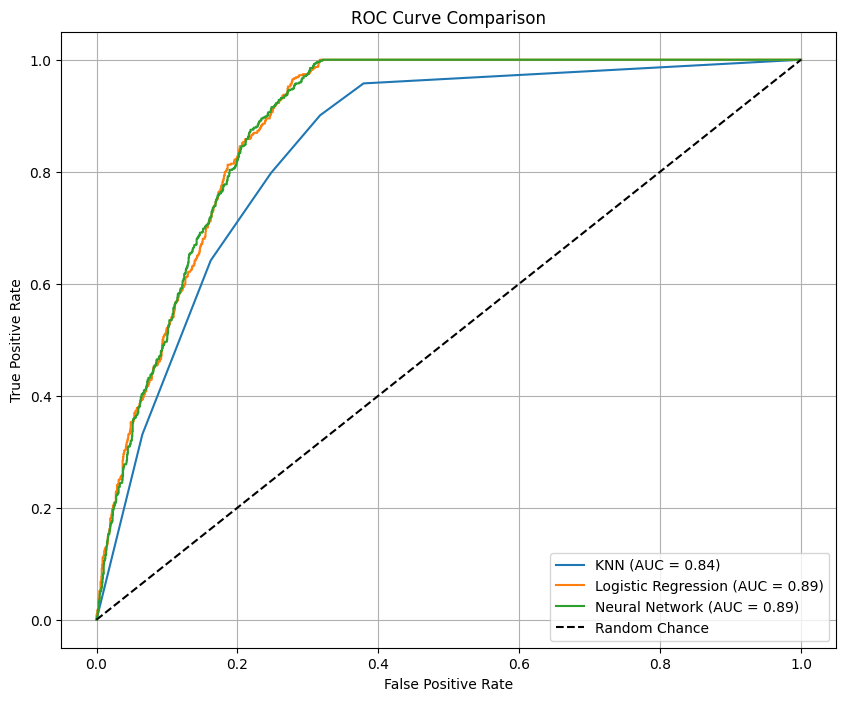

In [ ]:
# Plot ROC Curves
from sklearn.metrics import precision_score, recall_score, roc_curve, auc, roc_auc_score


# For ROC/AUC we need the raw probabilities
y_prob_knn = knn.predict_proba(X_test)[:, 1]
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]
y_prob_nn_balanced = model.predict(X_test).ravel()  # NN gives probability directly

# Compute precision & recall
metrics_data = {
    'Model': ['KNN', 'Logistic Regression', 'Neural Network'],
    'Precision': [
        precision_score(y_test, y_pred_knn_balanced),
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_nn_balanced)
    ],
    'Recall': [
        recall_score(y_test, y_pred_knn_balanced),
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_nn_balanced)
    ],
    'AUC': [
        roc_auc_score(y_test, y_prob_knn),
        roc_auc_score(y_test, y_prob_logistic),
        roc_auc_score(y_test, y_prob_nn_balanced)
    ]
}

metrics_df = pd.DataFrame(metrics_data)
print(metrics_df)

plt.figure(figsize=(10, 8))

models_probs = {
    'KNN': y_prob_knn,
    'Logistic Regression': y_prob_logistic,
    'Neural Network': y_prob_nn_balanced
}

for model_name, y_prob in models_probs.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = df.drop('Segmentation_C', axis=1)
y = df['Segmentation_C']

# Split the data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5355, 25)
X_test shape: (2296, 25)
y_train shape: (5355,)
y_test shape: (2296,)


In [ ]:
from imblearn.over_sampling import SMOTE

# Applying SMOTE to the training set only
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Train KNN on balanced data
knn = KNeighborsClassifier()
knn.fit(X_train_balanced, y_train_balanced)

# Predict on the original (imbalanced) test set
y_pred_knn_balanced = knn.predict(X_test)

In [ ]:
# accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn_balanced)
print("Accuracy:", knn_accuracy)

Accuracy: 0.8044425087108014


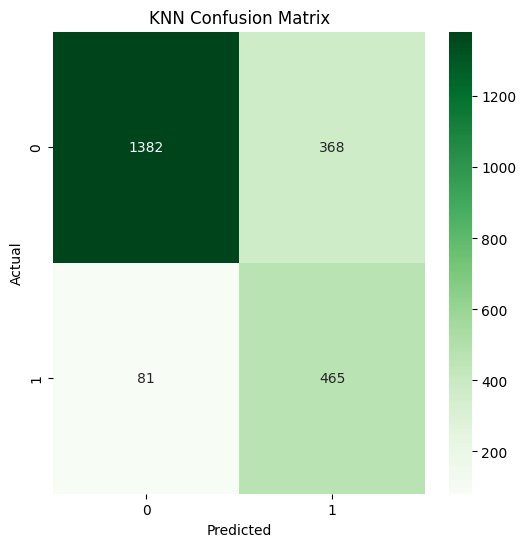

In [ ]:
# confusion matrix
knn_cm = confusion_matrix(y_test, y_pred_knn_balanced)

plt.figure(figsize=(6, 6))
sns.heatmap(knn_cm, annot=True, fmt='d', cmap='Greens', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.title("KNN Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# Classification report
knn_class_report = classification_report(y_test, y_pred_knn_balanced)
print("Classification Report:")
print(knn_class_report)

Classification Report:
              precision    recall  f1-score   support

       False       0.94      0.79      0.86      1750
        True       0.56      0.85      0.67       546

    accuracy                           0.80      2296
   macro avg       0.75      0.82      0.77      2296
weighted avg       0.85      0.80      0.82      2296



In [ ]:
logistic_model = LogisticRegression(class_weight='balanced')
logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

In [ ]:
# Accuracy
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
print("Accuracy:", logistic_accuracy)

Accuracy: 0.8192508710801394


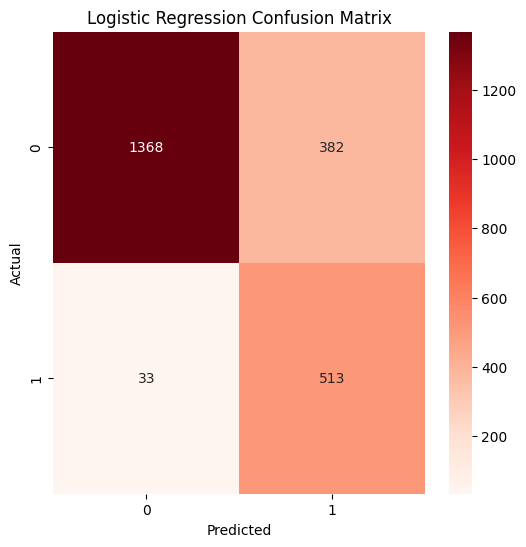

In [ ]:
# confusion matrix
logistic_cm = confusion_matrix(y_test, y_pred_logistic)

# Plotting confusion matrix using seaborn heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(logistic_cm, annot=True, fmt='d', cmap='Reds', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# Classification Report
log_class_report = classification_report(y_test, y_pred_logistic)
print("\nClassification Report:")
print(log_class_report)


Classification Report:
              precision    recall  f1-score   support

       False       0.98      0.78      0.87      1750
        True       0.57      0.94      0.71       546

    accuracy                           0.82      2296
   macro avg       0.77      0.86      0.79      2296
weighted avg       0.88      0.82      0.83      2296



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE

# SMOTE object
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# New class distribution
from collections import Counter
print("Balanced class distribution:", Counter(y_train_balanced))

# Neural network model

model = Sequential([
    Dense(64, input_dim=X_train_balanced.shape[1], activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.001),
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

# EarlyStopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train with balanced data
history = model.fit(X_train_balanced, y_train_balanced,
                             validation_data=(X_test, y_test),
                             epochs=100,
                             batch_size=32,
                             callbacks=[early_stop],
                             verbose=1)
# Evaluate the model
y_pred_nn = (model.predict(X_test) > 0.5).astype(int)

Balanced class distribution: Counter({False: 4080, True: 4080})
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


255/255 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6926 - loss: 0.6178 - val_accuracy: 0.7774 - val_loss: 0.4427
Epoch 2/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8402 - loss: 0.3634 - val_accuracy: 0.8088 - val_loss: 0.3688
Epoch 3/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8626 - loss: 0.3253 - val_accuracy: 0.8219 - val_loss: 0.3575
Epoch 4/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8542 - loss: 0.3282 - val_accuracy: 0.8197 - val_loss: 0.3570
Epoch 5/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8613 - loss: 0.3109 - val_accuracy: 0.8184 - val_loss: 0.3610
Epoch 6/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8691 - loss: 0.3059 - val_accuracy: 0.8188 - val_loss: 0.3498
Epoch 7/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8624 - loss: 0.3081 - val_accuracy: 0.8323 - val_loss: 0.3339
Epoch 8/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8679 - loss: 0.3017 - val_accuracy: 0.8240

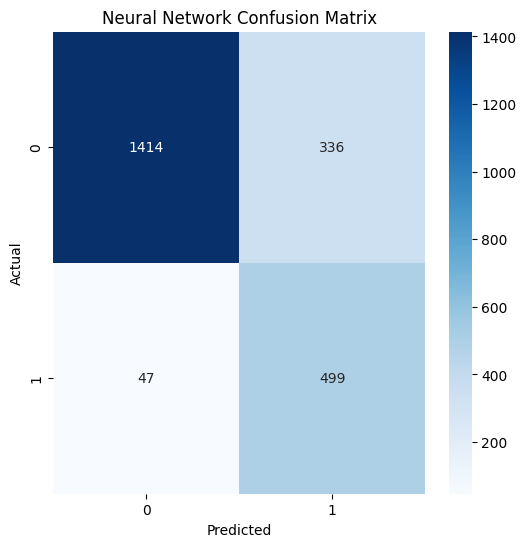

In [ ]:
# Confusion Matrix
nn_cm = confusion_matrix(y_test, y_pred_nn)
plt.figure(figsize=(6, 6))
sns.heatmap(nn_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'])
plt.title("Neural Network Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
#Classification Report
print("\nNeural Network Classification Report:")
print(classification_report(y_test, y_pred_nn))


Neural Network Classification Report:
              precision    recall  f1-score   support

       False       0.97      0.81      0.88      1750
        True       0.60      0.91      0.72       546

    accuracy                           0.83      2296
   macro avg       0.78      0.86      0.80      2296
weighted avg       0.88      0.83      0.84      2296



In [ ]:
# Predict probabilities on the original test set
y_prob_nn_balanced = model.predict(X_test)

# Convert probabilities to class labels (0 or 1)
y_pred_nn_balanced = (y_prob_nn_balanced > 0.5).astype(int)

# evaluate accuracy
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nn_balanced_accuracy = accuracy_score(y_test, y_pred_nn_balanced)
print(f"Neural Network Accuracy (after balancing): {nn_balanced_accuracy:.4f}")

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Neural Network Accuracy (after balancing): 0.8332


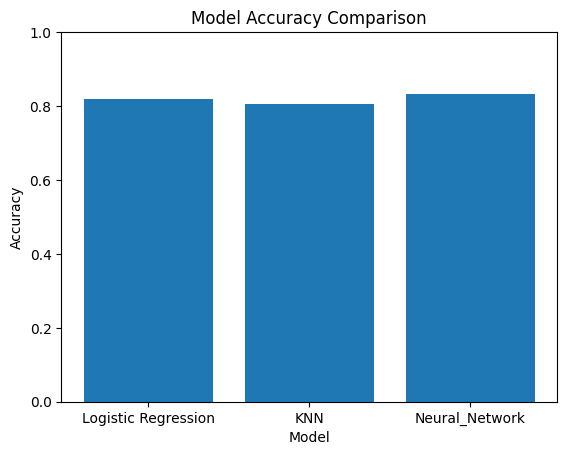

In [ ]:
accuracy_data = {
    'Model': ['Logistic Regression', 'KNN', 'Neural_Network'],
    'Accuracy': [logistic_accuracy, knn_accuracy, nn_balanced_accuracy]
}

accuracy_df = pd.DataFrame(accuracy_data)

# plt.figure(figsize=(8, 6))
plt.bar(accuracy_df['Model'], accuracy_df['Accuracy'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)
plt.show()

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
                 Model  Precision    Recall       AUC
0                  KNN   0.558223  0.851648  0.891370
1  Logistic Regression   0.573184  0.939560  0.927117
2       Neural Network   0.597605  0.913919  0.937433


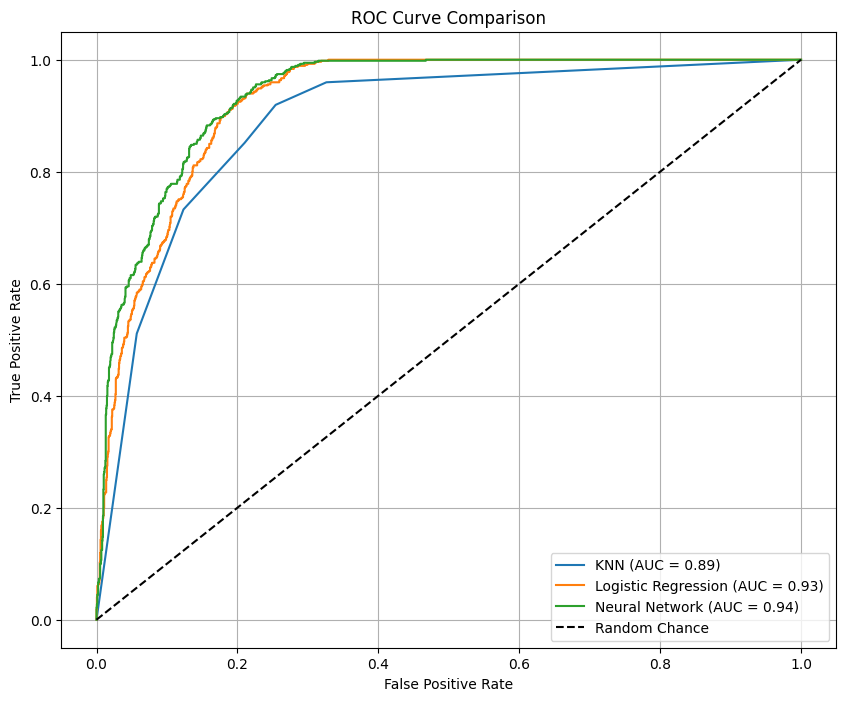

In [ ]:
# Plot ROC Curves
from sklearn.metrics import precision_score, recall_score, roc_curve, auc, roc_auc_score

# For ROC/AUC we need the raw probabilities
y_prob_knn = knn.predict_proba(X_test)[:, 1]
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]
y_prob_nn_balanced = model.predict(X_test).ravel()  # NN gives probability directly

# Compute precision & recall
metrics_data = {
    'Model': ['KNN', 'Logistic Regression', 'Neural Network'],
    'Precision': [
        precision_score(y_test, y_pred_knn_balanced),
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_nn_balanced)
    ],
    'Recall': [
        recall_score(y_test, y_pred_knn_balanced),
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_nn_balanced)
    ],
    'AUC': [
        roc_auc_score(y_test, y_prob_knn),
        roc_auc_score(y_test, y_prob_logistic),
        roc_auc_score(y_test, y_prob_nn_balanced)
    ]
}

metrics_df = pd.DataFrame(metrics_data)
print(metrics_df)

plt.figure(figsize=(10, 8))

models_probs = {
    'KNN': y_prob_knn,
    'Logistic Regression': y_prob_logistic,
    'Neural Network': y_prob_nn_balanced
}

for model_name, y_prob in models_probs.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = df.drop('Segmentation_D', axis=1)
y = df['Segmentation_D']

# Split the data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5355, 25)
X_test shape: (2296, 25)
y_train shape: (5355,)
y_test shape: (2296,)


In [ ]:
from imblearn.over_sampling import SMOTE

# Applying SMOTE to the training set only
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Train KNN on balanced data
knn = KNeighborsClassifier()
knn.fit(X_train_balanced, y_train_balanced)

# Predict on the original (imbalanced) test set
y_pred_knn_balanced = knn.predict(X_test)

In [ ]:
# accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn_balanced)
print("Accuracy:", knn_accuracy)

Accuracy: 0.8122822299651568


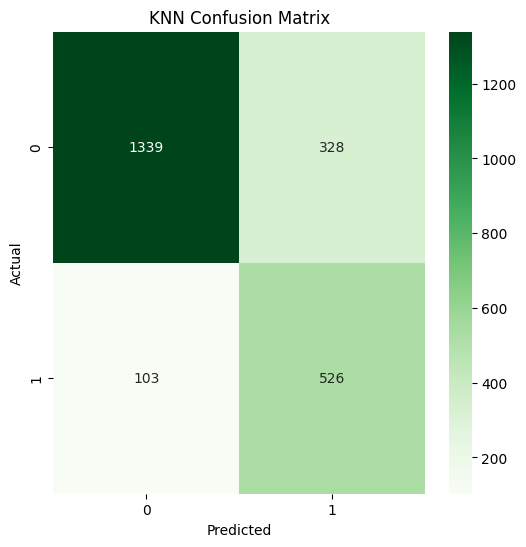

In [ ]:
# confusion matrix
knn_cm = confusion_matrix(y_test, y_pred_knn_balanced)

plt.figure(figsize=(6, 6))
sns.heatmap(knn_cm, annot=True, fmt='d', cmap='Greens', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.title("KNN Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# Classification report
knn_class_report = classification_report(y_test, y_pred_knn_balanced)
print("Classification Report:")
print(knn_class_report)

Classification Report:
              precision    recall  f1-score   support

       False       0.93      0.80      0.86      1667
        True       0.62      0.84      0.71       629

    accuracy                           0.81      2296
   macro avg       0.77      0.82      0.79      2296
weighted avg       0.84      0.81      0.82      2296



In [ ]:
logistic_model = LogisticRegression(class_weight='balanced')
logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

In [ ]:
# Accuracy
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
print("Accuracy:", logistic_accuracy)

Accuracy: 0.8148954703832753


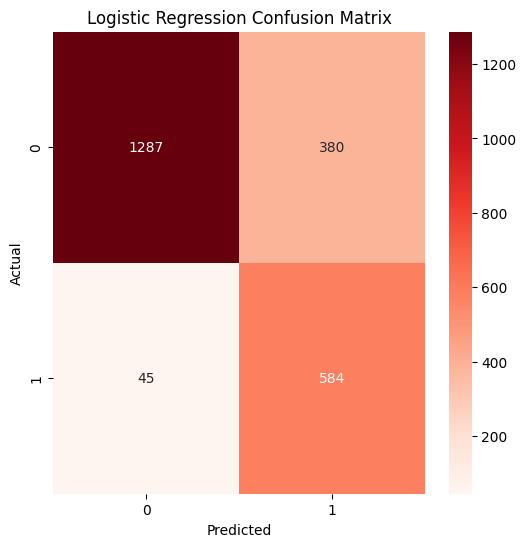

In [ ]:
# confusion matrix
logistic_cm = confusion_matrix(y_test, y_pred_logistic)

# Plotting confusion matrix using seaborn heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(logistic_cm, annot=True, fmt='d', cmap='Reds', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# Classification Report
log_class_report = classification_report(y_test, y_pred_logistic)
print("\nClassification Report:")
print(log_class_report)


Classification Report:
              precision    recall  f1-score   support

       False       0.97      0.77      0.86      1667
        True       0.61      0.93      0.73       629

    accuracy                           0.81      2296
   macro avg       0.79      0.85      0.80      2296
weighted avg       0.87      0.81      0.82      2296



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE

# SMOTE object
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# New class distribution
from collections import Counter
print("Balanced class distribution:", Counter(y_train_balanced))

# Neural network model

model = Sequential([
    Dense(64, input_dim=X_train_balanced.shape[1], activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.001),
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

# EarlyStopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train with balanced data
history = model.fit(X_train_balanced, y_train_balanced,
                             validation_data=(X_test, y_test),
                             epochs=100,
                             batch_size=32,
                             callbacks=[early_stop],
                             verbose=1)
# Evaluate the model
y_pred_nn = (model.predict(X_test) > 0.5).astype(int)

Balanced class distribution: Counter({False: 3888, True: 3888})


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6772 - loss: 0.6391 - val_accuracy: 0.8371 - val_loss: 0.3565
Epoch 2/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8171 - loss: 0.3829 - val_accuracy: 0.8227 - val_loss: 0.3243
Epoch 3/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8376 - loss: 0.3459 - val_accuracy: 0.8140 - val_loss: 0.3235
Epoch 4/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8305 - loss: 0.3540 - val_accuracy: 0.8201 - val_loss: 0.3209
Epoch 5/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8336 - loss: 0.3341 - val_accuracy: 0.7905 - val_loss: 0.3435
Epoch 6/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8360 - loss: 0.3346 - val_accuracy: 0.8079 - val_loss: 0.3244
Epoch 7/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8514 - loss: 0.3191 - val_accuracy: 0.8284 - val_loss: 0.3113
Epoch 8/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8527 - loss: 0.3151 - val_accu

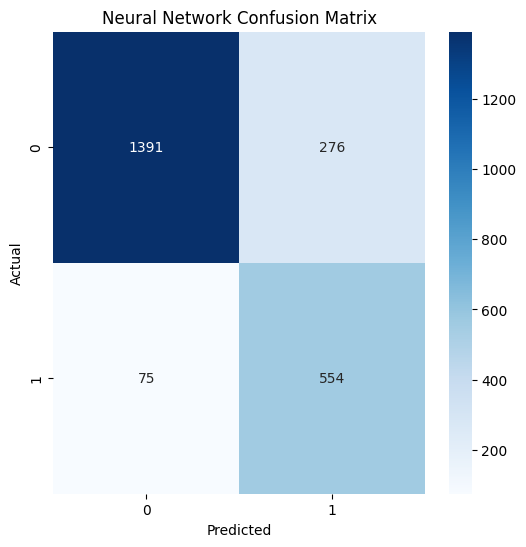

In [ ]:
# Confusion Matrix
nn_cm = confusion_matrix(y_test, y_pred_nn)
plt.figure(figsize=(6, 6))
sns.heatmap(nn_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'])
plt.title("Neural Network Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
#Classification Report
print("\nNeural Network Classification Report:")
print(classification_report(y_test, y_pred_nn))


Neural Network Classification Report:
              precision    recall  f1-score   support

       False       0.95      0.83      0.89      1667
        True       0.67      0.88      0.76       629

    accuracy                           0.85      2296
   macro avg       0.81      0.86      0.82      2296
weighted avg       0.87      0.85      0.85      2296



In [ ]:
# Predict probabilities on the original test set
y_prob_nn_balanced = model.predict(X_test)

# Convert probabilities to class labels (0 or 1)
y_pred_nn_balanced = (y_prob_nn_balanced > 0.5).astype(int)

# evaluate accuracy
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nn_balanced_accuracy = accuracy_score(y_test, y_pred_nn_balanced)
print(f"Neural Network Accuracy (after balancing): {nn_balanced_accuracy:.4f}")

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Neural Network Accuracy (after balancing): 0.8471


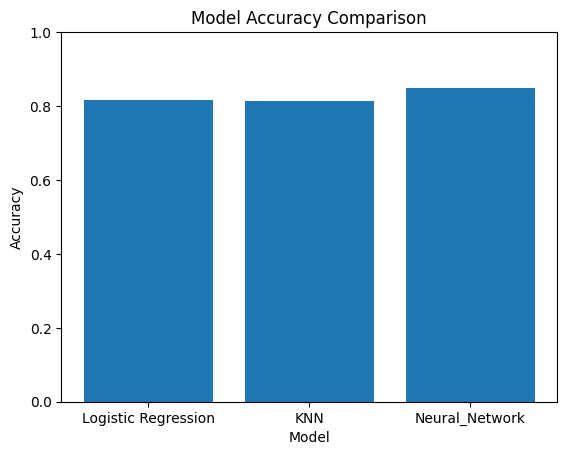

In [ ]:
accuracy_data = {
    'Model': ['Logistic Regression', 'KNN', 'Neural_Network'],
    'Accuracy': [logistic_accuracy, knn_accuracy, nn_balanced_accuracy]
}

accuracy_df = pd.DataFrame(accuracy_data)

# plt.figure(figsize=(8, 6))
plt.bar(accuracy_df['Model'], accuracy_df['Accuracy'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)
plt.show()

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
                 Model  Precision    Recall       AUC
0                  KNN   0.615925  0.836248  0.888484
1  Logistic Regression   0.605809  0.928458  0.937556
2       Neural Network   0.667470  0.880763  0.940440


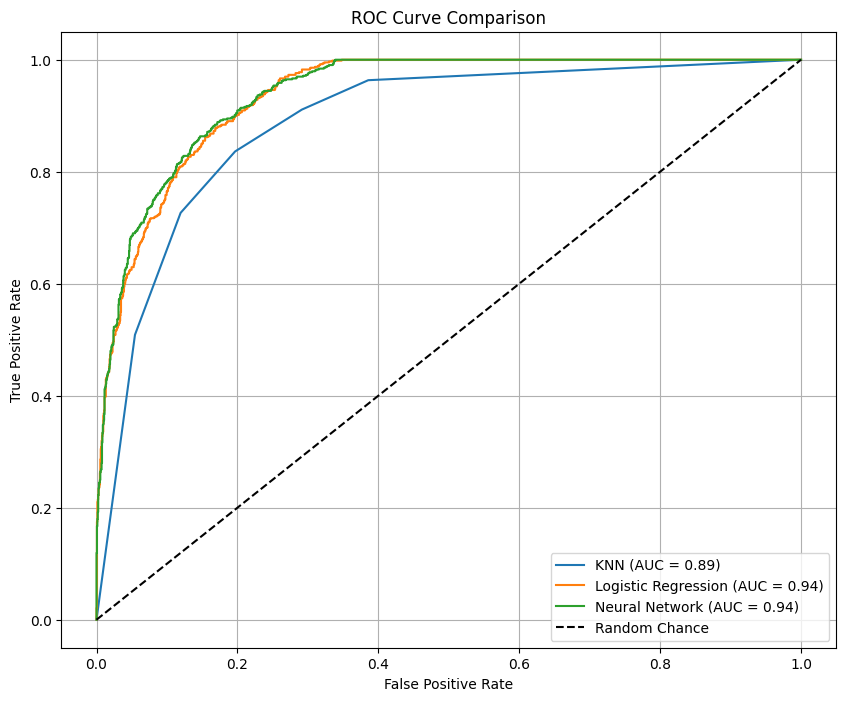

In [ ]:
# Plot ROC Curves
from sklearn.metrics import precision_score, recall_score, roc_curve, auc, roc_auc_score


# For ROC/AUC we need the raw probabilities
y_prob_knn = knn.predict_proba(X_test)[:, 1]
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]
y_prob_nn_balanced = model.predict(X_test).ravel()  # NN gives probability directly

# Compute precision & recall
metrics_data = {
    'Model': ['KNN', 'Logistic Regression', 'Neural Network'],
    'Precision': [
        precision_score(y_test, y_pred_knn_balanced),
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_nn_balanced)
    ],
    'Recall': [
        recall_score(y_test, y_pred_knn_balanced),
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_nn_balanced)
    ],
    'AUC': [
        roc_auc_score(y_test, y_prob_knn),
        roc_auc_score(y_test, y_prob_logistic),
        roc_auc_score(y_test, y_prob_nn_balanced)
    ]
}

metrics_df = pd.DataFrame(metrics_data)
print(metrics_df)

plt.figure(figsize=(10, 8))

models_probs = {
    'KNN': y_prob_knn,
    'Logistic Regression': y_prob_logistic,
    'Neural Network': y_prob_nn_balanced
}

for model_name, y_prob in models_probs.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid()
plt.show()